Nama : Muhammad Naufal Yazid Akbar

NIM  : 23.11.5870


# OPTIMASI RANDOM FOREST MENGGUNAKAN GIRDSEARCHCV DAN SMOTE UNTUK KLASIFIKASI TINGKAT KEBUGARAN BERDASARKAN DATA KESEHATAN DENGAN DEPLOYMENT BERBASIS STREAMLIT

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Input Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/DATA MINING/dataset/fitness_dataset.csv')
print("5 Data Awal:")
print(df.head())

5 Data Awal:
   age  height_cm  weight_kg  heart_rate  blood_pressure  sleep_hours  \
0   56        152         65        69.6           117.0          NaN   
1   69        186         95        60.8           114.8          7.5   
2   46        192        103        61.4           116.4          NaN   
3   32        189         83        60.2           130.1          7.0   
4   60        175         99        58.1           115.8          8.0   

   nutrition_quality  activity_index smokes gender  is_fit  
0               2.37            3.97     no      F       1  
1               8.77            3.19      0      F       1  
2               8.20            2.03      0      F       0  
3               6.18            3.68      0      M       1  
4               9.95            4.83    yes      F       1  


## EDA

### Info Dataset

In [4]:
print("\nInfo Dataset:")
print(df.info())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB
None


### Statistik Dataset

In [5]:
print("\nStatistik Deskriptif:")
print(df.describe())


Statistik Deskriptif:
               age   height_cm    weight_kg   heart_rate  blood_pressure  \
count  2000.000000  2000.00000  2000.000000  2000.000000     2000.000000   
mean     49.114000   174.53300    83.540500    70.288600      119.908850   
std      17.926564    14.37175    25.852534    11.846339       14.578032   
min      18.000000   150.00000    30.000000    45.000000       90.000000   
25%      34.000000   162.00000    64.000000    62.100000      109.700000   
50%      49.000000   174.00000    83.000000    70.250000      120.000000   
75%      65.000000   187.00000   102.000000    78.425000      129.800000   
max      79.000000   199.00000   250.000000   118.600000      171.200000   

       sleep_hours  nutrition_quality  activity_index       is_fit  
count  1840.000000        2000.000000     2000.000000  2000.000000  
mean      7.513315           5.035140        2.999040     0.399500  
std       1.502031           2.864156        1.136383     0.489918  
min       4.0000

### Distribusi Data Pada Kelas Target

Jumlah Tidak Bugar (0): 1201
Jumlah Bugar (1): 799


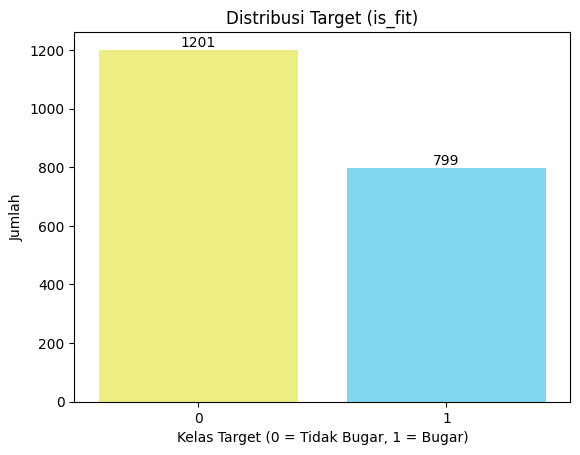

In [6]:
# Hitung jumlah tiap kelas
counts = df['is_fit'].value_counts().sort_index()

# Tampilkan dalam bentuk teks
print(f"Jumlah Tidak Bugar (0): {counts[0]}")
print(f"Jumlah Bugar (1): {counts[1]}")

# Visualisasi
ax = sns.countplot(
    x='is_fit',
    data=df,
    order=[0,1],
    palette=['#FEFF70', '#70E0FF']
)

# Tambahin angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribusi Target (is_fit)')
plt.xlabel('Kelas Target (0 = Tidak Bugar, 1 = Bugar)')
plt.ylabel('Jumlah')
plt.show()

### Transformasi Data Kategorikal untuk Analisis

In [7]:
df_eda = df.copy()
df_eda['smokes'] = df_eda['smokes'].astype(str).str.lower().str.strip()
df_eda['smokes'] = df_eda['smokes'].map({'yes': 1, '1': 1, 'no': 0, '0': 0})
df_eda['gender'] = df_eda['gender'].map({'M': 1, 'F': 0})

### Korelasi Antar Fitur (Makin dekat hasilnya dengan angka 1 maka korelasinya makin kuat)

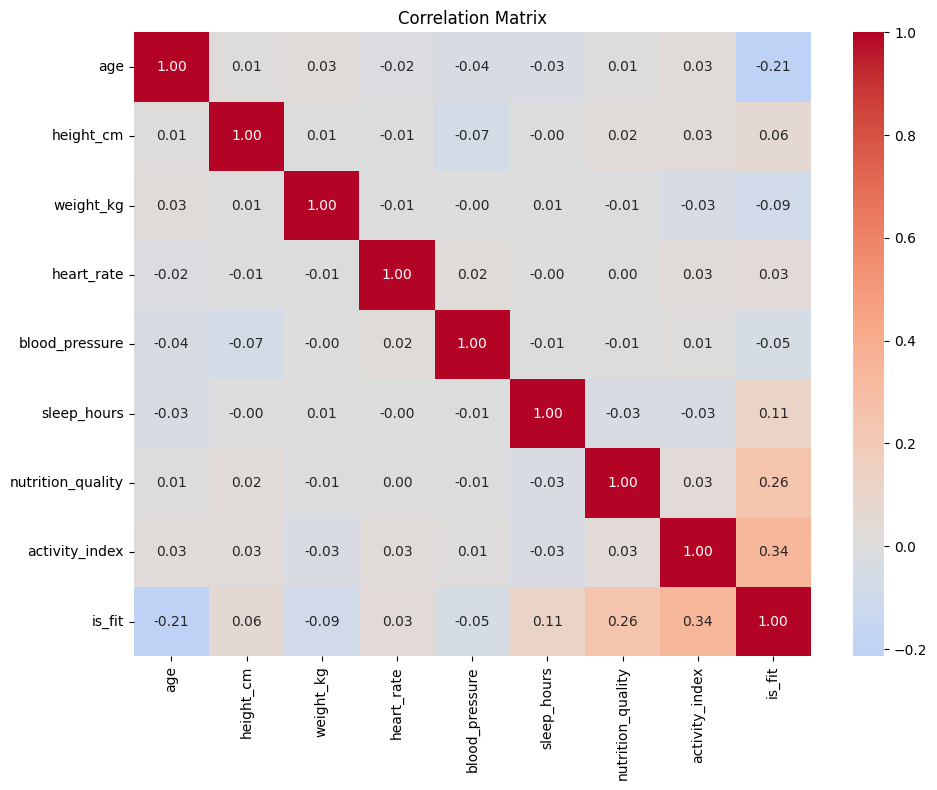

In [8]:
# Cek korelasi (hanya kolom numerik)
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
corr['is_fit'].sort_values(ascending=False)

,is_fit
is_fit,1.000000
activity_index,0.343187
nutrition_quality,0.255423
sleep_hours,0.109074
height_cm,0.064877
heart_rate,0.032763
blood_pressure,-0.051010
weight_kg,-0.088033
age,-0.214002


### Cek Outlier

In [10]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if df[col].nunique() > 6]

outlier_before = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_before.append({
        "Kolom": col,
        "Jumlah_Outlier": outliers.shape[0]
    })

outlier_before = pd.DataFrame(outlier_before)

print("=== Jumlah Outlier per Kolom Numerik ===")
print(outlier_before.sort_values(by="Jumlah_Outlier", ascending=False))

=== Jumlah Outlier per Kolom Numerik ===
               Kolom  Jumlah_Outlier
2          weight_kg              21
3         heart_rate              10
4     blood_pressure               4
5        sleep_hours               2
0                age               0
1          height_cm               0
6  nutrition_quality               0
7     activity_index               0


### Visualisasi Outlier

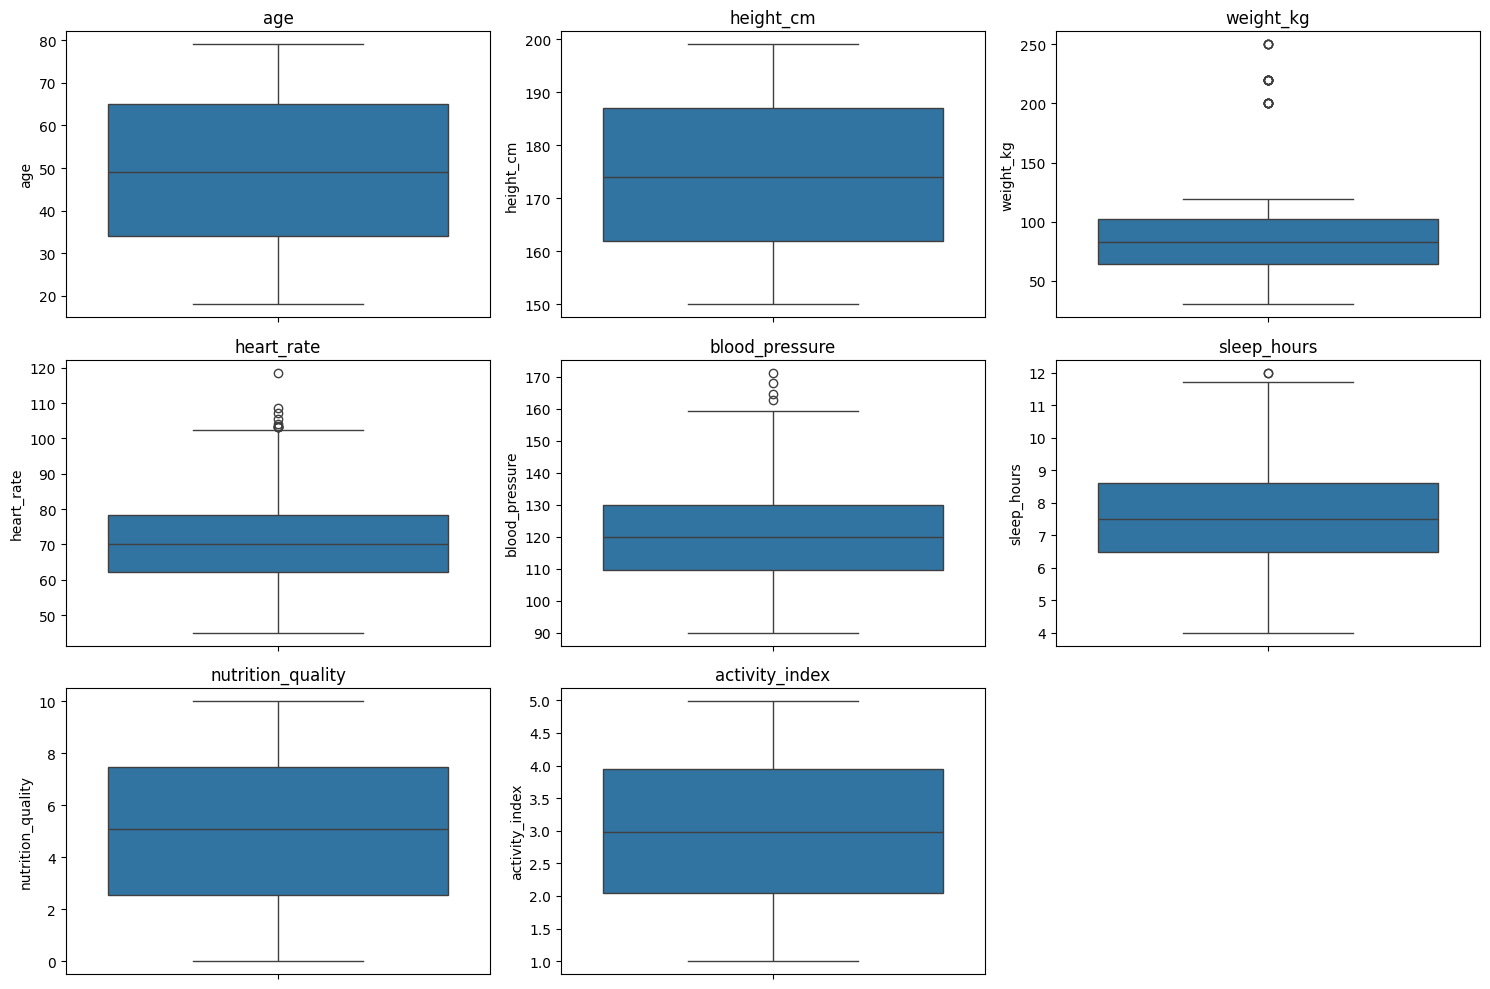

In [11]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)//3)+1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Cek Missing Value

In [12]:
print("\nMissing Value:")
print(df.isnull().sum())


Missing Value:
age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64


## Preprocessing

### Copy Dataset

In [13]:
df_model = df.copy()

### Encoding Fitur Kategorik

In [14]:
df_model['smokes'] = df_model['smokes'].astype(str).str.strip().str.lower()
df_model['smokes'] = df_model['smokes'].replace({
    'yes': 1,
    'no': 0,
    '1': 1,
    '0': 0
})

df_model['gender'] = df_model['gender'].map({'M': 1, 'F': 0})

### Imputasi Missing Value Menggunakan Modus

In [15]:
df_model['sleep_hours'].fillna(df_model['sleep_hours'].mode()[0], inplace=True)

### Cek Missing Value Setelah di Imputasi

In [16]:
print("\nMissing Value Setelah Imputasi:")
print(df_model.isnull().sum())


Missing Value Setelah Imputasi:
age                  0
height_cm            0
weight_kg            0
heart_rate           0
blood_pressure       0
sleep_hours          0
nutrition_quality    0
activity_index       0
smokes               0
gender               0
is_fit               0
dtype: int64


### Penanganan Outlier Menggunakan Capping (mengganti nilai outlier dengan batas atas dan batas bawah)

In [17]:
# Kolom numerik yang dicek outlier
outlier_cols = ['weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours']

for col in outlier_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_model[col] = df_model[col].clip(lower=lower, upper=upper)

for col in outlier_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_model[(df_model[col] < lower) | (df_model[col] > upper)]

    print(f"{col}: {outliers.shape[0]} outlier")

weight_kg: 0 outlier
heart_rate: 0 outlier
blood_pressure: 0 outlier
sleep_hours: 0 outlier


### Train-Test Split / Pembagian Data

In [18]:
X = df_model.drop('is_fit', axis=1)
y = df_model['is_fit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y  # data dibagi 9:1 (data train/latih 90% dan data test/uji 10%)
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (1800, 10)
X_test : (200, 10)


### Normalisasi Data

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## SMOTE (Menyeimbangkan data training dan mengubah distribusi kelas agar sama)

In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE:", np.bincount(y_train))
print("Sesudah SMOTE:", np.bincount(y_train_smote))

Sebelum SMOTE: [1081  719]
Sesudah SMOTE: [1081 1081]


##Modeling Random Forest dengan GirdSearchCV

### Pencarian Parameter max_depth dan n_estimator dengan range tertentu

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_1 = {
    'max_depth': range(1, 21),
    'n_estimators': range(10, 101, 1)
}

grid_1 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_1,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_1.fit(X_train_smote, y_train_smote)

best_max_depth = grid_1.best_params_['max_depth']
best_n_estimators = grid_1.best_params_['n_estimators']

print("Tahap 1 - Best Params:", grid_1.best_params_)
print("Tahap 1 - Best Accuracy:", grid_1.best_score_)

Tahap 1 - Best Params: {'max_depth': 20, 'n_estimators': 62}
Tahap 1 - Best Accuracy: 0.8265695834402532


### Pencarian Parameter main_samples_leaf dengan range tertentu

In [22]:
param_grid_2 = {
    'min_samples_leaf': range(1, 11)
}

grid_2 = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        max_depth=best_max_depth,
        n_estimators=best_n_estimators
    ),
    param_grid_2,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_2.fit(X_train_smote, y_train_smote)

best_min_samples_leaf = grid_2.best_params_['min_samples_leaf']

print("Tahap 2 - Best Params:", grid_2.best_params_)
print("Tahap 2 - Best Accuracy:", grid_2.best_score_)

Tahap 2 - Best Params: {'min_samples_leaf': 1}
Tahap 2 - Best Accuracy: 0.8265695834402532


### Pencarian Parameter main_samples_split dengan range tertentu

In [23]:
param_grid_3 = {
    'min_samples_split': range(2, 11)
}

grid_3 = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        max_depth=best_max_depth,
        n_estimators=best_n_estimators,
        min_samples_leaf=best_min_samples_leaf
    ),
    param_grid_3,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_3.fit(X_train_smote, y_train_smote)

best_min_samples_split = grid_3.best_params_['min_samples_split']

print("Tahap 3 - Best Params:", grid_3.best_params_)
print("Tahap 3 - Accuracy:", grid_3.best_score_)

Tahap 3 - Best Params: {'min_samples_split': 2}
Tahap 3 - Accuracy: 0.8265695834402532


### Model Final Random Forest

In [24]:
final_model = RandomForestClassifier(
    random_state=42,
    max_depth=best_max_depth,
    n_estimators=best_n_estimators,
    min_samples_leaf=best_min_samples_leaf,
    min_samples_split=best_min_samples_split,
    class_weight='balanced'
)

final_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=62,
                       random_state=42)

## Evaluasi Model Final Random Forest

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test_scaled)

print("\nFinal Model Evaluation (Dengan SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final Model Evaluation (Dengan SMOTE):
Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       120
           1       0.73      0.70      0.71        80

    accuracy                           0.78       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.77      0.78      0.77       200



In [26]:
import pickle

# nama file model
filename = 'random_forest_model.sav'

# simpan model ke file .sav
with open(filename, 'wb') as file:
    pickle.dump(final_model, file)

print("Model berhasil disimpan ke:", filename)

Model berhasil disimpan ke: random_forest_model.sav


Model masih sedikit bias ke kelas mayoritas, walaupun sudah SMOTE

### Confusion Matrix Final Model Random Forest

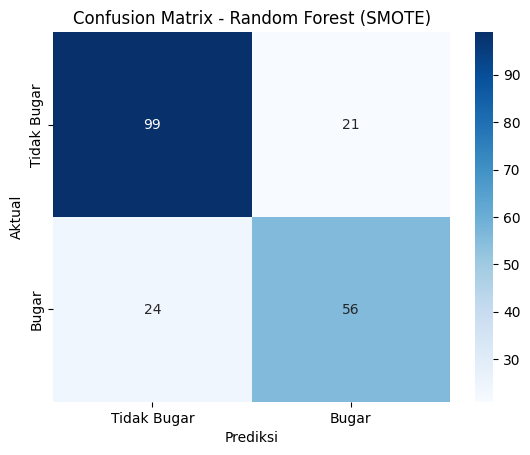

In [27]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Bugar', 'Bugar'],
            yticklabels=['Tidak Bugar', 'Bugar'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Random Forest (SMOTE)')
plt.show()

Dari confusion matrix, model berhasil mengklasifikasikan 99 data tidak bugar dan 56 data bugar dengan benar. Namun masih terdapat kesalahan sebanyak 21 false positive dan 24 false negative, yang menunjukkan model masih perlu ditingkatkan terutama dalam membedakan kelas bugar.

### Kurva ROC-AUC untuk Mengukur kemampuan model membedakan kelas (lebih stabil dibanding accuracy pada data imbalanced)

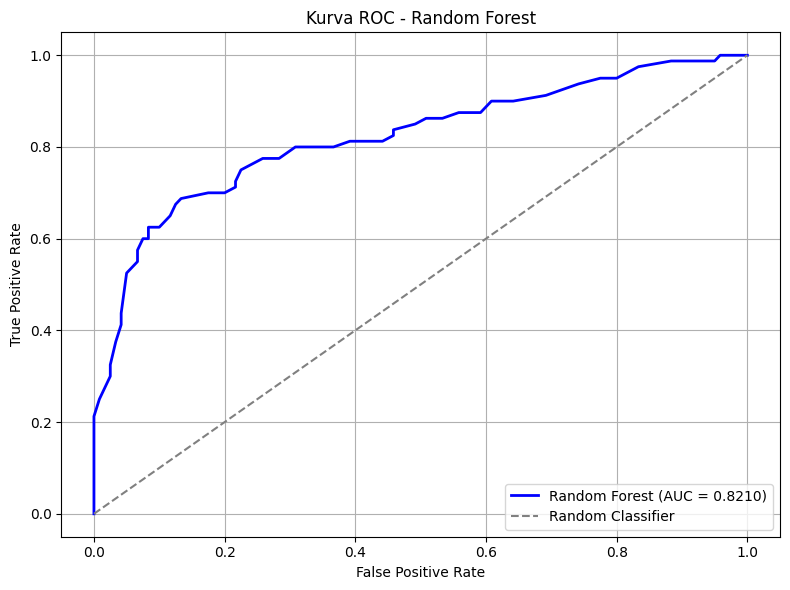

ROC-AUC Score: 0.8210


In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = final_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

Kurva ROC menunjukkan hubungan antara True Positive Rate dan False Positive Rate. Dari grafik terlihat bahwa kurva model berada jauh di atas garis random, yang berarti model memiliki kemampuan klasifikasi yang baik. Nilai AUC sebesar 0.82 menunjukkan bahwa model mampu membedakan kelas bugar dan tidak bugar dengan cukup baik.